In [1]:
%load_ext autoreload
from cellworld_npx.recording import *
import warnings
import pandas as pd
from scipy.signal import butter, filtfilt, hilbert
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d
from cellworld_npx.plotting import display_oasis_world
from matplotlib.gridspec import GridSpec


In [2]:
%autoreload
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None

behavior_folder = 'data/behavior'
spike_folder = 'data/spikes/CA021/2024-05-24_13-14-05'
R = Recording(spike_folder=spike_folder, behavior_database=behavior_folder)

lfp_arr = f'./data/processed_data/{os.path.split(R.experiment_name)[-1]}_decimated_lfp.npy'
timestamps_arr = f'./data/processed_data/{os.path.split(R.experiment_name)[-1]}_decimated_timestamps.npy'
theta_arr = f'./data/processed_data/{os.path.split(R.experiment_name)[-1]}_theta_band.npy'
delta_arr = f'./data/processed_data/{os.path.split(R.experiment_name)[-1]}_delta_band.npy'
theta_hilbert = f'./data/processed_data/{os.path.split(R.experiment_name)[-1]}_theta_hilbert.npy'
delta_hilbert = f'./data/processed_data/{os.path.split(R.experiment_name)[-1]}_delta_hilbert.npy'
r_processed = f'./data/behavior/{os.path.split(R.experiment_name)[-1]}_recording.pkl'
pre_post_theta_fig = f'./data/processed_data/{os.path.split(R.experiment_name)[-1]}_pre_post_theta.png'

VELOCITY_CM_S = 234
FS = 1500

In [ ]:
R.process()
R.save()

No entrance video found
no start sample or sync messages found
no start sample or sync messages found
1 3356 516 -5.46036521079422 863
1 3356 367 -5.41435125166141 1528
1 3356 255 -5.374309465492879 2134
1 3356 550 -5.382292036687882 2688
1 3356 24 -5.361079688294784 2579
1 3356 3356 -7.599195534174483 0

RECORDING data/behavior/OASIS_20240524_1314_CA021_oasis_island7_02_O7FULLBOT
	Behavioral experiments (5): 5 episodes, 29.17 minutes, 89.16 samples/s
		Experiment 0: data/behavior/OASIS_20240524_1314_CA021_oasis_island7_02_O7FULLBOT
		Experiment 1: data/behavior/OASIS_20240524_1327_CA021_oasis_island7_02_O7FULLBOT
		Experiment 2: data/behavior/OASIS_20240524_1339_CA021_oasis_island7_02_O7FULLBOT
		Experiment 3: data/behavior/OASIS_20240524_1349_CA021_oasis_island7_02_O7FULLBOT
		Experiment 4: data/behavior/OASIS_20240524_1356_CA021_oasis_island7_02_O7FULLBOT
	Neuronal recording: Neuropix-PXI-108.ProbeA, Neuropixels 2.0 - Multishank, 30000 samples/s
		data/spikes/CA021/2024-05-24_13-14-

Building episode dictionary...: 100%|██████████| 5/5 [00:34<00:00,  6.90s/it]


No entrance video found
no start sample or sync messages found
1 3356 516 -5.46036521079422 863
1 3356 367 -5.41435125166141 1528
1 3356 255 -5.374309465492879 2134
1 3356 550 -5.382292036687882 2688
1 3356 24 -5.361079688294784 2579
1 3356 3356 -7.599195534174483 0
No entrance pose labels found -- could not add entrance pose


AttributeError: 'Recording' object has no attribute 'experiments'

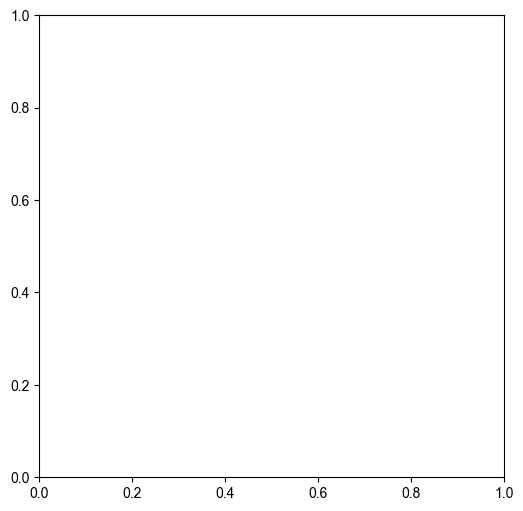

In [4]:
from cellworld_npx.plotting import display_oasis_world

fig, ax = plt.subplots(1,1, figsize=(6,6));
display_oasis_world(R.experiments[0], R.world, ax=ax);
ax.plot(R.df['prey_location_x'], R.df['prey_location_y'], 'k', zorder=10)
ax.plot(R.df['predator_location_x'], R.df['predator_location_y'], 'r')

average velocity 12109    25.112661
12110    25.670227
12111    26.189953
12112    26.683793
12113    27.215079
           ...    
12193    33.224977
12194    33.917709
12195    34.667272
12196    35.411079
12197    36.083990
Name: prey_velocity, Length: 89, dtype: float64cm/s


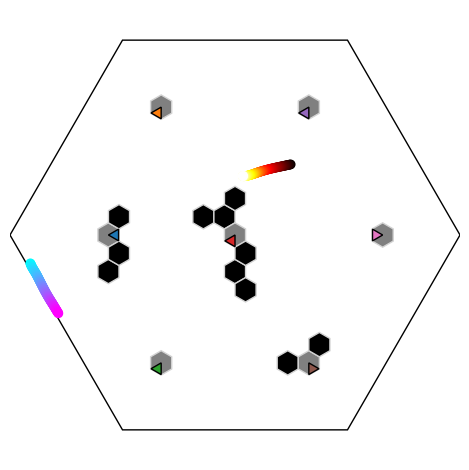

In [ ]:
theta_event_times = [1000, 1001]
t_i = (R.df.time_stamp > theta_event_times[0]) & (R.df.time_stamp < theta_event_times[1])
print(f'average velocity {R.df.prey_velocity[t_i] * VELOCITY_CM_S}cm/s')

fig, ax = plt.subplots(1,1)
display_oasis_world(R.experiments[0], R.world, ax=ax);
ax.scatter(R.df['prey_location_x'][t_i], R.df['prey_location_y'][t_i], c=R.df['time_stamp'][t_i], cmap='cool')
ax.scatter(R.df['predator_location_x'][t_i], R.df['predator_location_y'][t_i], c=R.df['time_stamp'][t_i], cmap='hot')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_aspect('equal')

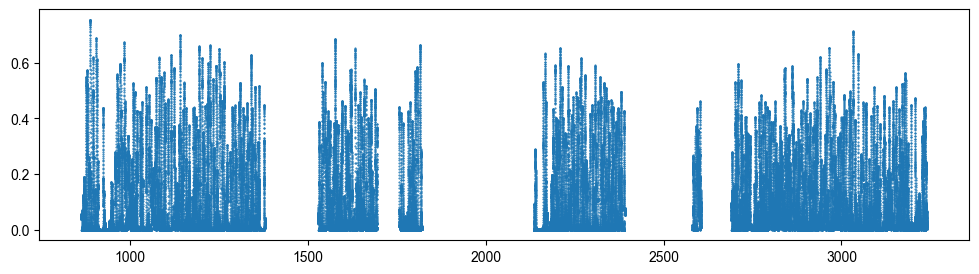

In [18]:
%matplotlib inline
fig, ax = plt.subplots(1,1, figsize=(12,3));
ax.plot(R.df['time_stamp'], R.df['prey_velocity'], '.', ms=1)
# ax.plot(R.df['time_stamp'], R.df['prey_velocity'], '-', color='Tab:blue', lw=1, zorder=-1)

In [45]:
%autoreload
from kilosort.io import *
factor = 20
decimated_signals, decimated_freq = R.decimate_lfp(verbose=True, factor=factor, chunk_time=2, hp_filter=False, whiten=False, dshift=False)

Neuropix-PXI-108.ProbeA


100%|██████████| 1678/1678 [04:04<00:00,  6.87it/s]


In [10]:
def bin_x_theta(x_theta, t, bins, channels=[]):
    bin_idx = np.digitize(t, bins) - 1  # t -> 0..n_bins-1
    n_bins = len(bins) - 1

    x_binned = np.zeros(n_bins)
    for i in range(n_bins):
        mask = bin_idx == i
        if np.any(mask):
            if channels:
                sum=0
                for ch in channels:
                    sum += np.mean(np.abs(hilbert(x_theta[ch, mask])))
                # x_binned[i] = np.mean([np.sum(np.abs(hilbert(x_theta[ch, mask]))) for ch in channels], axis=0)
                x_binned[i] = sum/len(channels)
                print(i, x_binned[i])
            else:
                x_binned[i] = np.abs(x_theta[:, mask].mean())

    t_binned = 0.5 * (bins[:-1] + bins[1:])
    return x_binned, t_binned

def bin_velocity(v, v_t, bins):
    bin_idx = np.digitize(v_t, bins) - 1  # v_t -> 0..n_bins-1
    n_bins = len(bins) - 1

    v_binned = np.zeros(n_bins)
    for i in range(n_bins):
        mask = bin_idx == i
        if np.any(mask):
            v_binned[i] = np.abs(v[mask].mean())
    
    v_t_binned = 0.5 * (bins[:-1] + bins[1:])
    return v_binned, v_t_binned


def bound_data(t, v_t, tmin, tmax):
    mask_t = (t >= tmin) & (t <= tmax)
    mask_v = (v_t >= tmin) & (v_t <= tmax)
    return mask_t, mask_v

In [10]:
np.save(lfp_arr, decimated_signals['Neuropix-PXI-108.ProbeA']['x'])
np.save(timestamps_arr, decimated_signals['Neuropix-PXI-108.ProbeA']['t_corrected'])

NameError: name 'decimated_signals' is not defined

In [ ]:
x = np.load(lfp_arr)
t = np.load(timestamps_arr)

def bandpass(x, band, sampling_freq, order=2):
    nyq_max_freq = sampling_freq/2
    b, a = butter(order, band/nyq_max_freq, btype='band')
    return filtfilt(b, a, x)

theta_band = np.array([6, 12])
# delta_band = np.array([0.5, 4])
x_theta = bandpass(x, theta_band, FS)
# x_delta = bandpass(x, delta_band, FS)

np.save(theta_arr, x_theta)
# np.save(delta_arr, x_delta)


In [9]:
delta_band = np.array([0.5, 4])
x_delta = bandpass(x, delta_band, decimated_freq)
np.save(delta_arr, x_delta)

In [ ]:
# def bin_x_theta(x_theta, t, binwidth=0.4):
#     bin_size_signal = int(binwidth * (len(t) / (t[-1] - t[0]))) # elements per bin of BINWIDTH seconds
#     n_bins = x_theta.shape[1] // bin_size_signal
#     x_trimmed = x_theta[:, :n_bins * bin_size_signal]
#     x_binned = np.abs(x_trimmed.reshape(384, n_bins, bin_size_signal).mean(axis=(0, 2)))
#     t_binned = t[: n_bins*bin_size_signal : bin_size_signal]  
#     return x_binned, t_binned

# # --- bin velocity ---
# def bin_velocity(v, v_t, binwidth=0.4):
#     bin_size_vel = int(binwidth * (len(v) / (v_t[-1] - v_t[0])))
#     n_bins_vel = len(v) // bin_size_vel
#     v_binned = v[:n_bins_vel * bin_size_vel].reshape(n_bins_vel, bin_size_vel).mean(axis=1)
#     v_t_binned = v_t[: n_bins_vel*bin_size_vel : bin_size_vel]
#     return v_binned, v_t_binned

(1000.0, 1050.0)

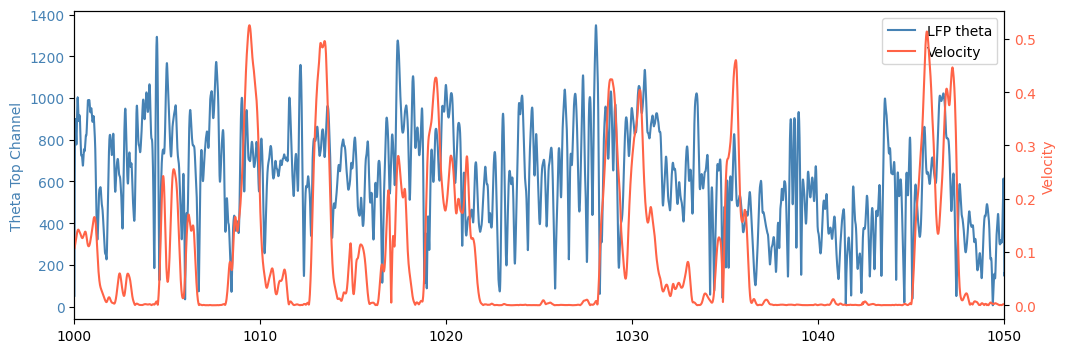

In [14]:
x_theta = np.load(theta_arr)
t = np.load(timestamps_arr)

R = load_recording_from_file(r_processed)
v = np.array(R.df['prey_velocity'])
v_t = np.array(R.df['time_stamp'])

x_theta_channel_avg = x_theta.mean(axis=0)
tmin, tmax = 1000, 1050
mask_t, mask_v = bound_data(t, v_t, tmin, tmax)

# top channel
row_sums = np.abs(x_theta).sum(axis=1) 
top_theta = x_theta[np.argmax(row_sums)]
top_theta_hilbert = np.abs(hilbert(top_theta[mask_t]))
# top10_channels = np.argsort(row_sums)[-10:] 
# top10_rows = x_theta[top10_channels]
# x_theta_top = top10_rows.mean(axis=0)

fig, ax1 = plt.subplots(figsize=(12, 4))
# ax1.plot(t[mask_t], np.abs(x_theta_channel_avg[mask_t]), color='steelblue', label='LFP (theta)')
ax1.plot(t[mask_t], top_theta_hilbert, color='steelblue', label='LFP theta')
ax1.set_ylabel('Theta Top Channel', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(v_t[mask_v], v[mask_v], color='tomato', label='Velocity')
ax2.set_ylabel('Velocity', color='tomato')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='tomato')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)
ax1.set_xlim(tmin, tmax)


(2000,)
215
(599,)
0 504422.2308752864
215
(599,)
1 497298.0263972046
215
(600,)
2 491528.6715787906
215
(599,)
3 278553.5478968103
215
(600,)
4 308345.1993964001
215
(599,)
5 406308.4587486994
215
(599,)
6 388169.281005176
215
(600,)
7 379999.1278809238
215
(599,)
8 449224.50226197625
215
(600,)
9 570337.3781832205
215
(599,)
10 442001.3787677542
215
(599,)
11 422153.7019623847
215
(600,)
12 558253.7689657373
215
(599,)
13 503770.3348517446
215
(600,)
14 265779.7048968116
215
(599,)
15 436347.2842523118
215
(599,)
16 288529.3507929776
215
(600,)
17 440782.0994891577
215
(599,)
18 587378.979501127
215
(600,)
19 518570.54234625766
215
(599,)
20 266762.9861095657
215
(599,)
21 200453.18689265815
215
(600,)
22 419674.42450263153
215
(599,)
23 463657.2541508818
215
(600,)
24 411298.3270216124
215
(599,)
25 318558.67102258373
215
(599,)
26 411509.62829811824
215
(600,)
27 395569.9416639084
215
(599,)
28 465304.57231604337
215
(600,)
29 411345.5661503253
215
(599,)
30 429232.5575409116
215
(

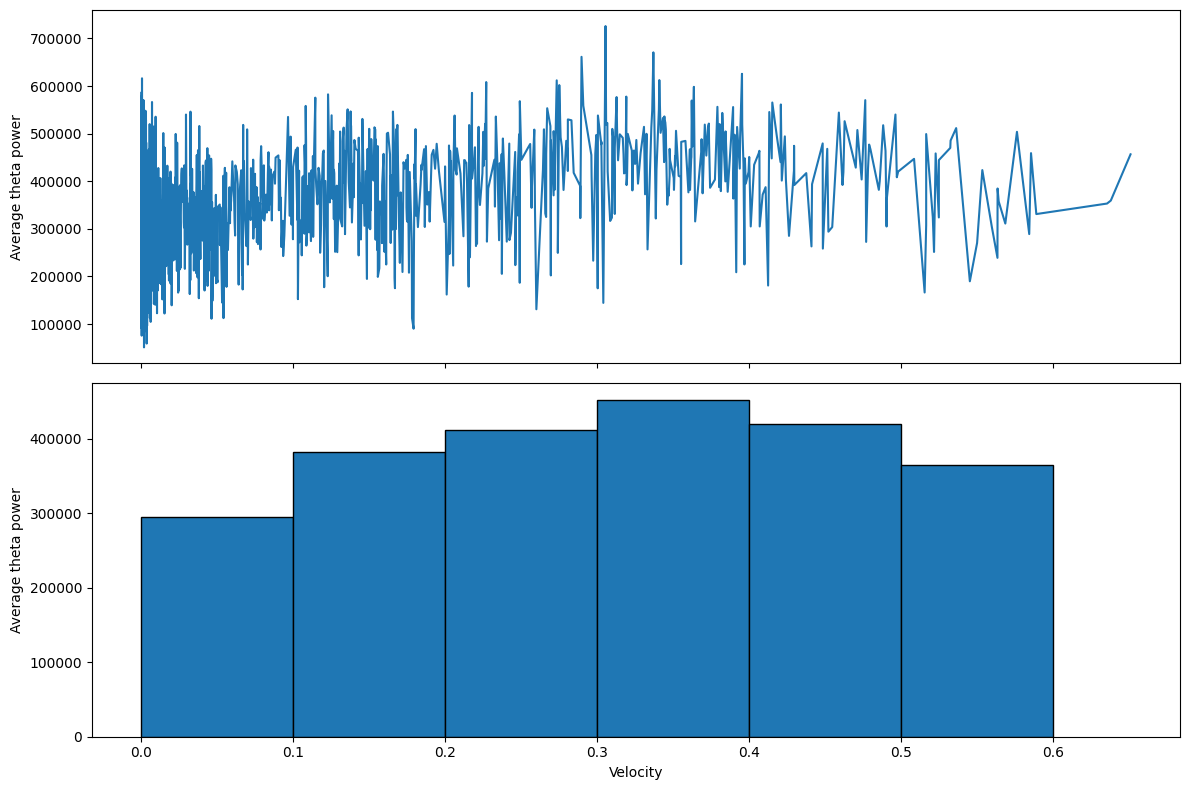

In [6]:
%autoreload 2
x_theta = np.load(theta_arr)
t = np.load(timestamps_arr)

R = load_recording_from_file(r_processed)
v = np.array(R.df['prey_velocity'])
v_t = np.array(R.df['time_stamp'])

# tmin, tmax = 870, 2600
tmin, tmax = 1000, 1800
bins = np.arange(tmin, tmax, 0.4)
print(bins.shape)

# x_binned, t_binned = bin_x_theta(x_theta, t, bins)

# use top x_theta channel
row_sums = np.abs(x_theta).sum(axis=1) 
# top_theta = x_theta[np.argmax(row_sums)]
x_binned, t_binned = bin_x_theta(x_theta, t, bins, channels=[np.argmax(row_sums)])
v_binned, v_t_binned = bin_velocity(v, v_t, bins)

print(t_binned.shape, v_t_binned.shape)
print(np.sum(np.isnan(v_binned)))

# bin over velocities
v_binwidth = 0.1
descending_v = np.argsort(v_binned)
print(np.nanmin(v_binned), np.nanmax(v_binned))
bins_v = np.arange(np.nanmin(v_binned), np.nanmax(v_binned), v_binwidth)
bin_indices = np.digitize(v_binned, bins_v)
x_binned_means = [x_binned[bin_indices == i].mean() if np.any(bin_indices == i) else 0
                  for i in range(1, len(bins_v))]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True) 
ax1.plot(v_binned[descending_v], x_binned[descending_v])
ax1.set_ylabel("Average theta power")
ax2.bar(bins_v[:-1], x_binned_means, width=v_binwidth, align='edge', edgecolor='black')
ax2.set_xlabel("Velocity")
ax2.set_ylabel("Average theta power")

plt.tight_layout()
plt.show()


[[ 148    8 2550]
 [ 149   40 2550]
 [ 150    8 2565]
 ...
 [  49  790 3600]
 [  50  758 3615]
 [  51  790 3615]]


(2000.0, 4000.0)

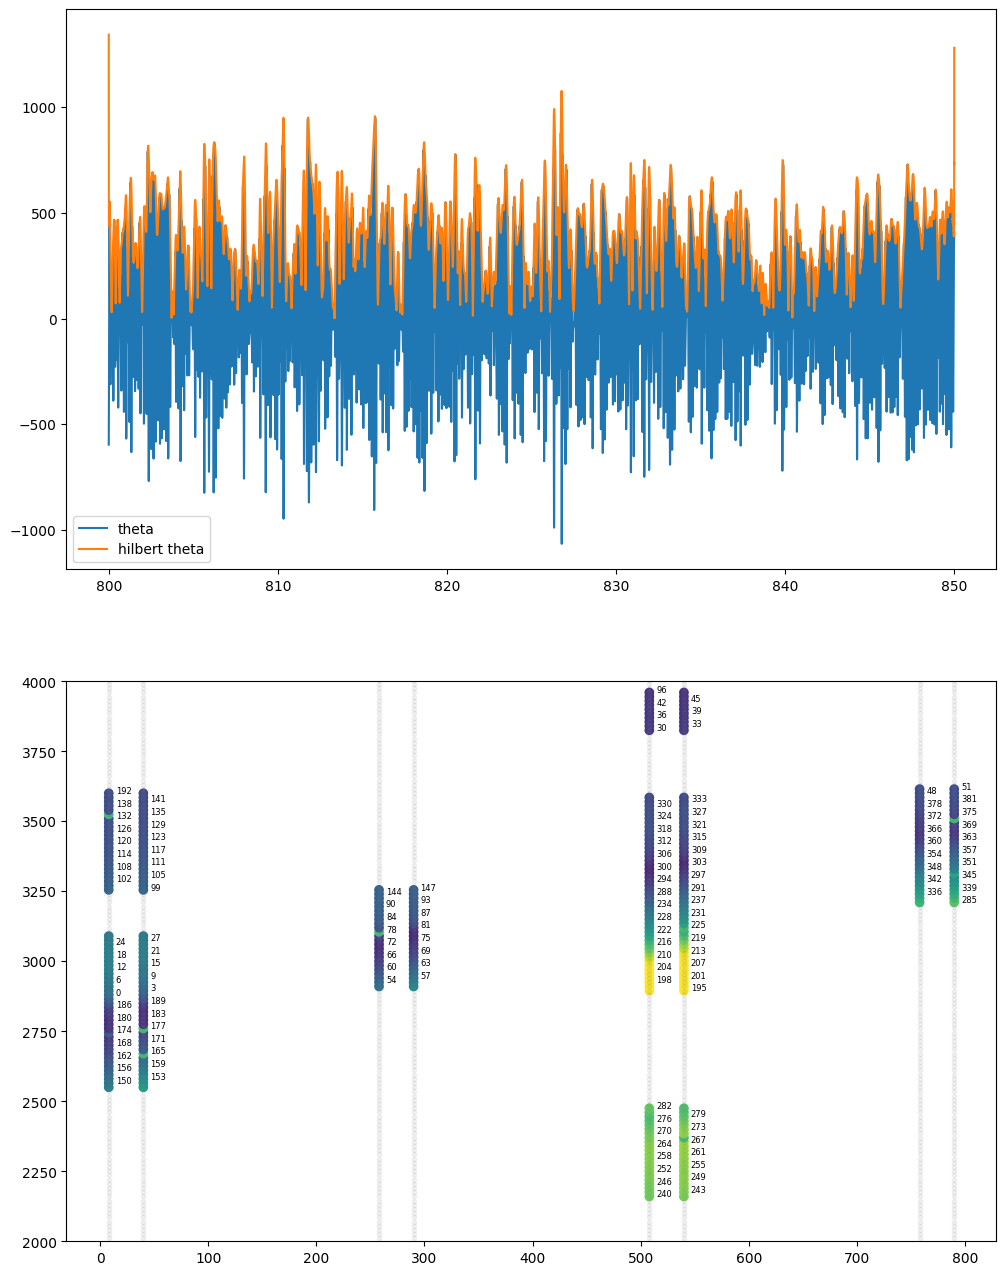

In [10]:
%autoreload 2
# %matplotlib qt5
R = load_recording_from_file(r_processed)
probe_sites = np.vstack(R.get_probe_sites()).T
channel_map = R.get_channel_map()[0]
print(channel_map)

# def power(x_theta):
#     amp = hilbert_torch(x_theta).abs() # abs of hilbert transform to get amplitude
#     return amp.cpu().numpy()

x_theta = np.load(theta_arr)
t = np.load(timestamps_arr)

def hilbert_power(x_theta, t):
    hilbert_x_theta = np.zeros(x_theta.shape[0])
    mask = (t >= 1000) & (t <= 1200)
    for i, channel in enumerate(x_theta):
        hilbert_x_theta[i] = np.sum(np.abs(hilbert(channel[mask])))
    return hilbert_x_theta

row_sums = np.abs(x_theta).sum(axis=1) 
top_theta = x_theta[np.argmax(row_sums)]
mask = (t >= 800) & (t <= 850)
hilbert_top_theta = np.abs(hilbert(top_theta[mask]))

hilbert_x_theta = hilbert_power(x_theta, t)
hilbert_color = hilbert_x_theta/np.nanmax(hilbert_x_theta)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16)) 
ax1.plot(t[mask], top_theta[mask], label='theta')
ax1.plot(t[mask], hilbert_top_theta, label='hilbert theta')
ax1.legend()
ax2.plot(probe_sites[:,0]+8, probe_sites[:,1], '.', alpha=0.1, color='grey')
# ax2.plot(channel_map[:,1], channel_map[:,2], 'k.', ms=10)
ax2.scatter(channel_map[:,1], channel_map[:,2], c=hilbert_color, cmap='viridis', vmin=0, vmax=0.5)
for ch, x, y in zip(channel_map[:,0], channel_map[:,1], channel_map[:,2]):
    if ch % 3 == 0:
        ax2.annotate(str(int(ch)), (x, y), textcoords="offset points", xytext=(5, 0), fontsize=6)
ax2.set_ylim(2000, 4000)


0 0
1 964
2 112
3 82
4 50
5 34
6 41
7 27
8 22
9 34
10 32
11 27
12 31
13 25
14 26
15 16
16 14
17 21
18 17
19 20
20 11
21 12
22 19
23 6
24 15
25 20
26 13
27 14
28 16
29 14
30 13
31 15
32 9
33 9
34 6
35 5
36 4
37 6
38 7
39 7
40 1
41 8
42 3
43 2
44 4
45 3
46 3
47 0
48 0
49 0


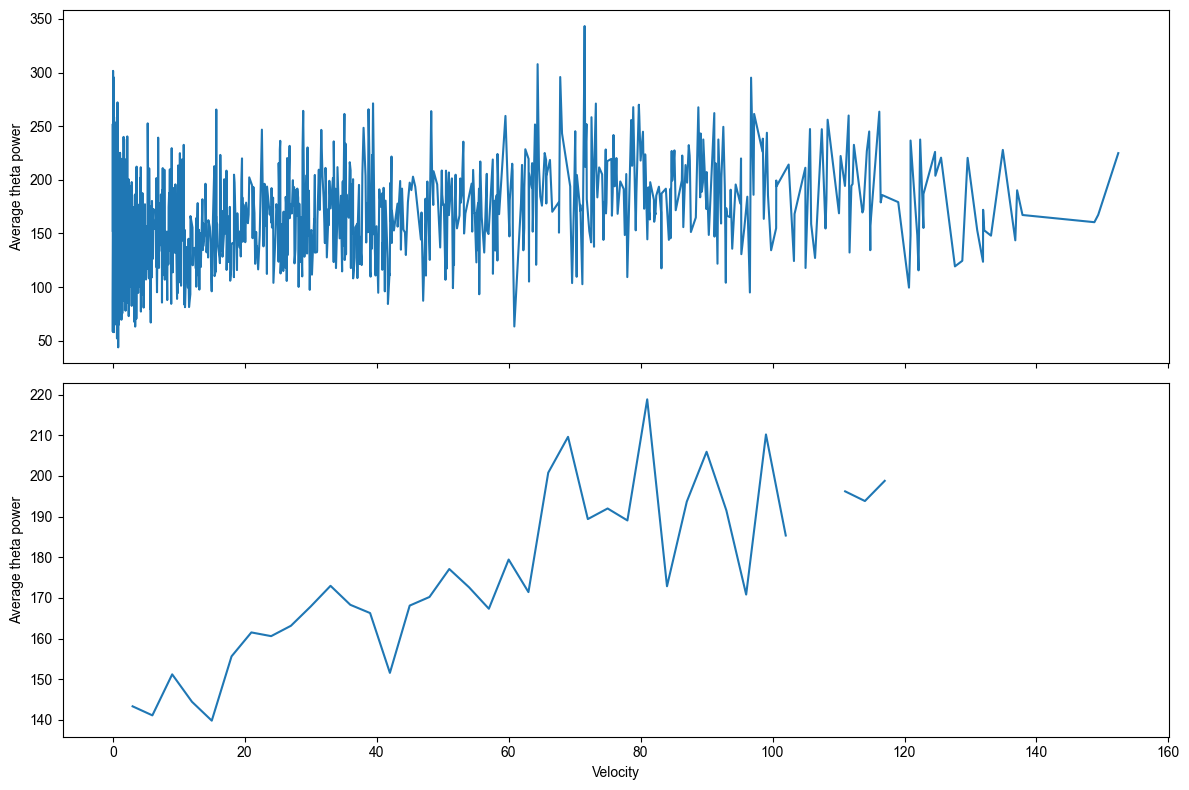

In [ ]:
channel_scatter = [28, 146, 225, 285, 201] # 4 shanks + dentate

tmin, tmax = 1000, 1800
bins = np.arange(tmin, tmax, 0.4)
v_cms = v * VELOCITY_CM_S

# x_binned, t_binned = bin_x_theta(x_theta, t, bins, channels=channel_scatter)
# v_binned, v_t_binned = bin_velocity(v_cms, v_t, bins)


v_binwidth = 3
bins_v = np.arange(np.nanmin(v_binned), np.nanmax(v_binned), v_binwidth)
bin_indices = np.digitize(v_binned, bins_v)

for i in range(len(bins_v)-1):
    print(i, x_binned[bin_indices == i].shape[0])
    if np.any(bin_indices == i) and x_binned[bin_indices == i].shape[0] > 5:
        x_binned_means[i] = x_binned[bin_indices == i].mean()
    else: 
        x_binned_means[i] = np.nan


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True) 
ax1.plot(v_binned[descending_v], x_binned[descending_v])
ax1.set_ylabel("Average theta power")
ax2.plot(bins_v[:-1], x_binned_means)
ax2.set_xlabel("Velocity")
ax2.set_ylabel("Average theta power")

plt.tight_layout()
plt.show()


In [ ]:
channels = [28, 146, 225, 285, 201]

# x_theta = np.load(theta_arr)
# x_delta = np.load(delta_arr)
# t = np.load(timestamps_arr)

def hilbert_x(x_band, channels, use_zscore=False):
    x_hilbert = np.zeros(x_band.shape[1])
    for ch in channels:
        h_ch = np.abs(hilbert(x_band[ch, :])) 
        x_hilbert += zscore(h_ch) if use_zscore else h_ch
    x_hilbert /= len(channels)
    return x_hilbert


x_theta_hilbert = hilbert_x(x_theta, channels, use_zscore=True)
x_delta_hilbert = hilbert_x(x_delta, channels, use_zscore=True)

# np.save(theta_hilbert, x_theta_hilbert)
# np.save(delta_hilbert, x_delta_hilbert)

# std = 0.006/(t[1]-t[0]) # samples in 6ms
# print(std)

# x_theta_hilbert_smooth = gaussian_filter1d(x_theta_hilbert, sigma=std)
# fig, ax = plt.subplots(1, figsize=(12, 4))
# ax.plot(t, x_theta_hilbert_smooth - x_theta_hilbert)
# plt.show()

In [6]:
# t = np.load(timestamps_arr)
# x_theta = np.load(theta_arr)
x_delta = np.load(delta_arr)

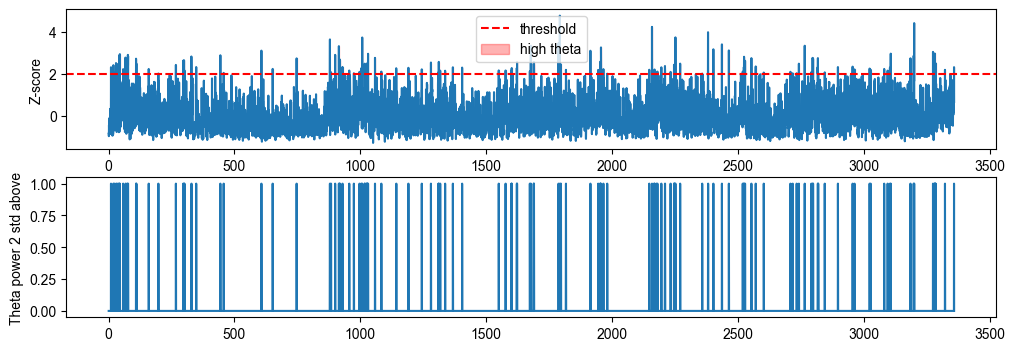

In [88]:
z = zscore(x_theta_hilbert_smooth)

bin_size_s = 0.4
bin_size_samples = int(bin_size_s / (t[1] - t[0]))
n_bins = len(z) // bin_size_samples

z_binned = z[:n_bins * bin_size_samples].reshape(n_bins, bin_size_samples)
t_binned = t[:n_bins * bin_size_samples].reshape(n_bins, bin_size_samples)

z_bin_means = z_binned.mean(axis=1)
t_bin_means = t_binned.mean(axis=1)

threshold = 2
high_theta = z_bin_means > threshold

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4))
ax1.plot(t_bin_means, z_bin_means)
ax1.axhline(threshold, color='r', linestyle='--', label='threshold')
ax1.fill_between(t_bin_means, z_bin_means, threshold, where=high_theta, alpha=0.3, color='red', label='high theta')
ax1.set_xlabel("Time")
ax1.set_ylabel("Z-score")
ax1.legend()

ax2.plot(t_bin_means, high_theta.astype(int))
ax2.set_ylabel(f'Theta power {threshold} std above')
plt.show()



In [8]:
# def detect_theta_states(x_theta_hilbert, x_delta_hilbert, fs, 
#                         ratio_threshold=2.0, min_duration_s=3.0):

#     min_samples = int(min_duration_s * fs)

#     ratio = np.divide(
#         x_theta_hilbert,
#         x_delta_hilbert,
#         out=np.zeros_like(x_theta_hilbert, dtype=float),
#         where=x_delta_hilbert > 0
#     )

#     above = ratio > ratio_threshold

#     # Pad with False so edges are always detected
#     padded = np.concatenate([[False], above, [False]])
#     diff = np.diff(padded.astype(np.int8))
#     starts = np.where(diff == 1)[0]   # rising edges
#     stops  = np.where(diff == -1)[0]  # falling edges (exclusive)

#     # Step 4: keep only runs >= min_samples
#     epochs = []
#     is_theta = np.zeros(len(x_theta_hilbert), dtype=bool)

#     for start, stop in zip(starts, stops):
#         if (stop - start) >= min_samples:
#             epochs.append((start, stop - 1))   # store as inclusive
#             is_theta[start:stop] = True

#     return ratio, is_theta, epochs


def detect_theta_states(x_theta_hilbert, x_delta_hilbert, fs,
                        ratio_threshold=2.0, min_duration_s=3.0,
                        max_gap_s=0.05):

    min_samples = int(min_duration_s * fs)
    max_gap_samples = int(max_gap_s * fs)

    ratio = np.divide(
        x_theta_hilbert,
        x_delta_hilbert,
        out=np.zeros_like(x_theta_hilbert, dtype=float),
        where=x_delta_hilbert > 0
    )

    above = ratio > ratio_threshold

    # Find raw runs above threshold
    padded = np.concatenate([[False], above, [False]])
    diff = np.diff(padded.astype(np.int8))
    starts = list(np.where(diff ==  1)[0])
    stops  = list(np.where(diff == -1)[0])  # exclusive

    # Merge runs separated by a gap <= max_gap_samples
    merged_starts = [starts[0]]
    merged_stops  = [stops[0]]

    for start, stop in zip(starts[1:], stops[1:]):
        gap = start - merged_stops[-1]
        if gap <= max_gap_samples:
            # bridge the gap — extend the previous run
            merged_stops[-1] = stop
        else:
            merged_starts.append(start)
            merged_stops.append(stop)

    # Apply minimum duration filter
    epochs = []
    is_theta = np.zeros(len(x_theta_hilbert), dtype=bool)

    for start, stop in zip(merged_starts, merged_stops):
        if (stop - start) >= min_samples:
            epochs.append((start, stop - 1))  # inclusive
            is_theta[start:stop] = True

    return ratio, is_theta, epochs


def plot_theta_epochs(t, ratio, is_theta, epochs, fs,
                      x_theta_hilbert, x_delta_hilbert, avg_velocity_thr=5):
    """
    Plot theta/delta ratio over time with theta epochs highlighted.
    Optionally overlay the theta and delta envelopes.
    """
    fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)


    ax1 = axes[0]
    ax1.plot(t, ratio, lw=0.8, color='steelblue', label='θ/δ ratio')

    ax1_r = ax1.twinx()
    ax1_r.plot(R.df.time_stamp, R.df.prey_velocity * VELOCITY_CM_S, lw=0.4, alpha=0.8, color='black', label='Velocity')
    ax1_r.set_ylim(0, 100)
    ax1_r.set_ylabel('Velocity (cm/s)')

    ax1.axhline(2.0, color='tomato', lw=1.0, ls='--', label='Threshold (2.0)')

    ax1.set_ylabel('θ / δ amplitude ratio')
    ax1.set_ylim(bottom=0)
    theta_patch = mpatches.Patch(color='gold', label='Theta state')
    theta_patch_stationary = mpatches.Patch(color='red', label='Theta state (stationary)')
    ax1.legend(handles=[ax1.lines[0], ax1.lines[1], ax1_r.lines[0], theta_patch, theta_patch_stationary],
              loc='upper right', fontsize=12)
    ax1.set_title(f'Theta state detection  —  {len(epochs)} epochs, '
                 f'{is_theta.sum() / fs:.1f} s total '
                 f'({100 * is_theta.mean():.1f}%)')


    ax2 = axes[1]
    ax2.plot(t, x_theta_hilbert, color='darkorange', lw=0.7, label='θ hilbert')
    ax2.plot(t, x_delta_hilbert, color='cornflowerblue', lw=0.7, label='δ hilbert')
    ax2.set_ylabel('Amplitude (a.u.)')
    ax2.legend(loc='upper right', fontsize=12)
    ax2.set_xlabel('Time (s)')
    ax2.set_xlim(860, 1000)

    for start, stop in epochs:
        velo_t_mask = (R.df.time_stamp > t[start]) & (R.df.time_stamp < t[stop])
        avg_velo = np.mean(R.df.prey_velocity[velo_t_mask]) * VELOCITY_CM_S
        if avg_velo < avg_velocity_thr:
            ax1.axvspan(t[start], t[stop], color='red', alpha=0.25, lw=0)
            ax2.axvspan(t[start], t[stop], color='red', alpha=0.25, lw=0)
        else:
            ax1.axvspan(t[start], t[stop], color='gold', alpha=0.25, lw=0)
            ax2.axvspan(t[start], t[stop], color='gold', alpha=0.25, lw=0)

    plt.tight_layout()
    # return fig


121


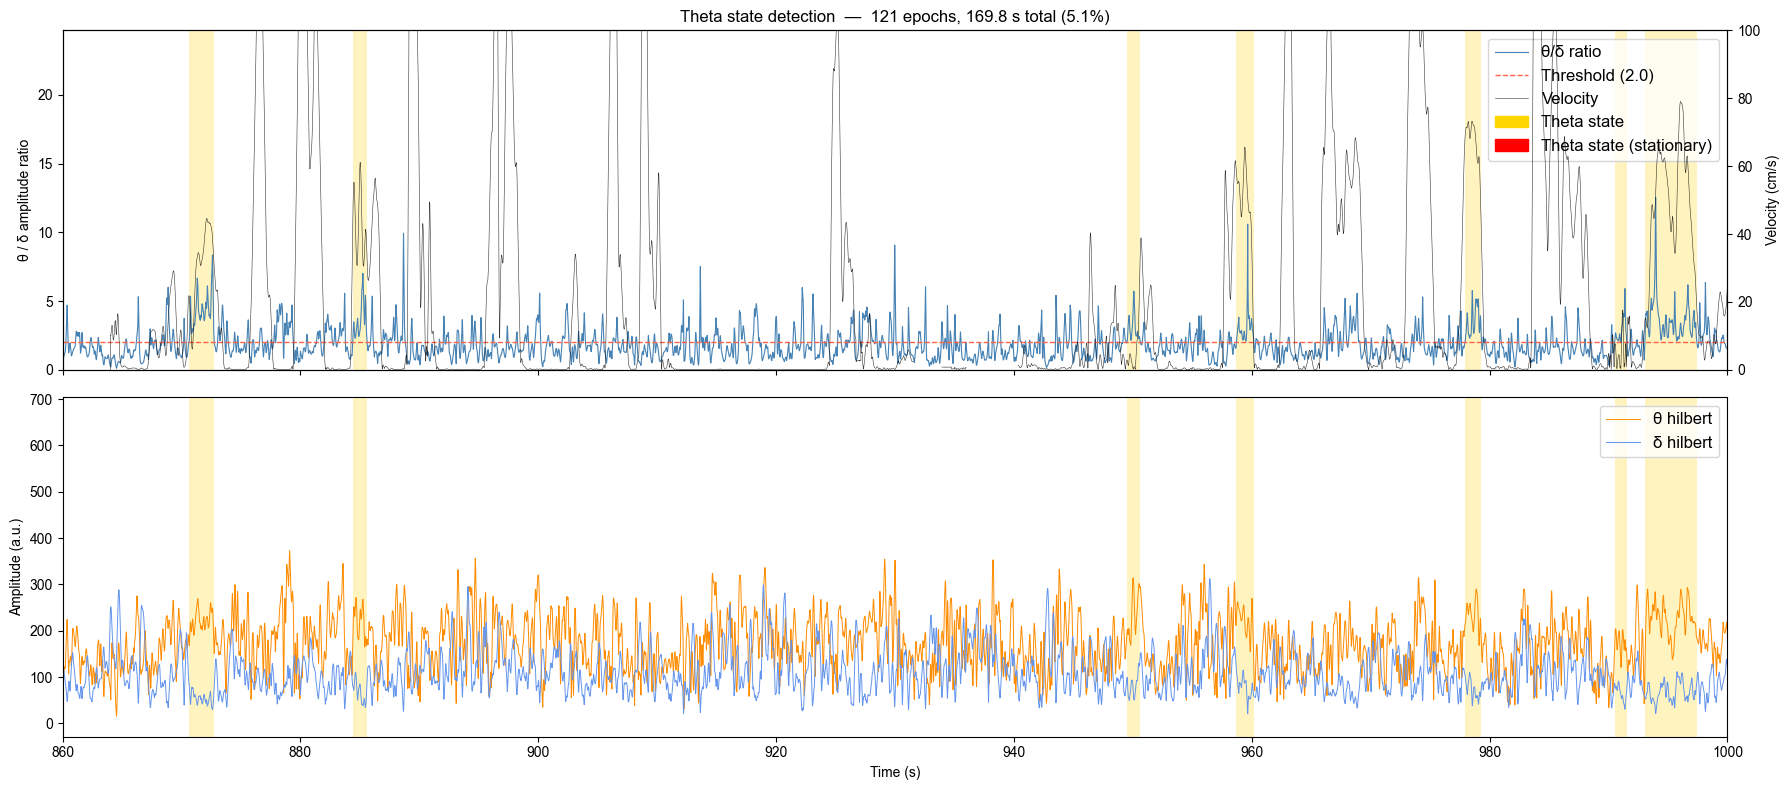

In [14]:
R = load_recording_from_file(r_processed)
theta_delta_ratio, is_theta, epochs = detect_theta_states(x_theta_hilbert, x_delta_hilbert, FS, ratio_threshold=2, min_duration_s=1, max_gap_s=0.05)
plot_theta_epochs(t, theta_delta_ratio, is_theta, epochs, FS, x_theta_hilbert, x_delta_hilbert, avg_velocity_thr=5)
# print(t[np.where(is_theta)[0]])
print(len(epochs))

1. what is happening when mouse is stationary and there is high theta power?
a. could be representing planning, these are sweep events, can we identify these periods and see if there is anything interesting happening at a behavioral level
b. did robot come into mouse's view? is robot close or closing distance to mouse? was mouse just chased and stopped to hide, is there high theta?
2. does theta precede the mouse's next action (with some lag)-- find all times where mouse initiated running and look at average theta power a little before and after

3. ripple events-- filter in 100-250Hz. make sure ripples are most frequently happening when mouse is stationary
a. z score the ripple band power, gaussian smooth it (std ~6 ms) and will take noisy power signal and make it smooth, threshold (i.e. zscore > 3, longer than 50ms, if two events within 50ms merge into one event), generates time indices of whether a ripple is happening. 
b. Sanity check: calculate mouse's velcity or position in those time windows
c. What is happening when these ripples are occurring? Are they occurring at certain locations more often, or when robot comes into view/closing in (theta questions)

0        -0.019981
1        -0.019501
2        -0.019022
3        -0.018525
4        -0.018006
            ...   
152634         NaN
152635         NaN
152636         NaN
152637         NaN
152638         NaN
Name: prey_location_x, Length: 152639, dtype: float64


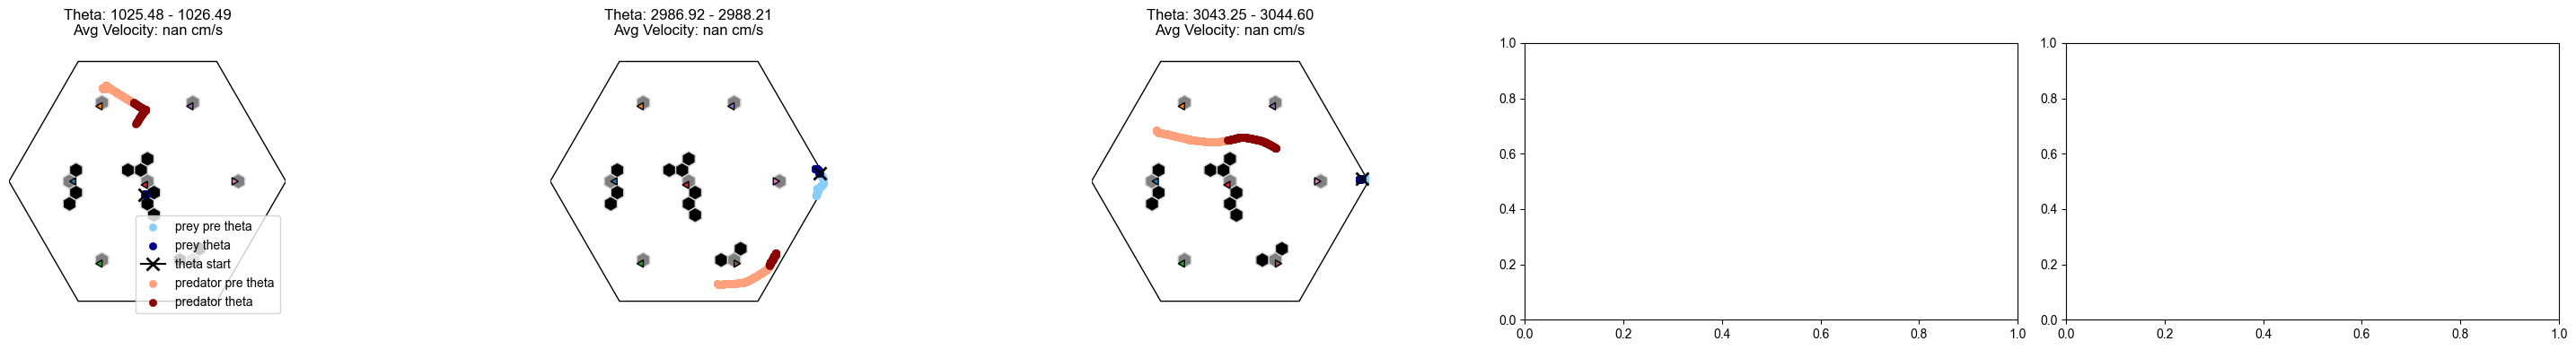

In [15]:
R = load_recording_from_file(r_processed)
OFFSET = 2

theta_event_times = t[epochs]
avg_velocity = np.zeros(len(epochs))
filtered_epochs = []

for i, epoch in enumerate(epochs):
    t_mask = (R.df.time_stamp > t[epoch[0]]) & (R.df.time_stamp < t[epoch[1]])
    avg_velocity[i] = np.mean(R.df.prey_velocity[t_mask]) * VELOCITY_CM_S
    if not np.isnan(avg_velocity[i]) and avg_velocity[i] < 5:
        filtered_epochs.append(epoch)

n_cols = 5
n_rows = math.ceil(len(filtered_epochs) / n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
ax = ax.flatten()  

for i, epoch in enumerate(filtered_epochs):
    pre_theta_offset, post_theta_offset = t[epoch[0]] - OFFSET, min(t[epoch[1]], t[epoch[0]] + OFFSET)
    t_pre_theta = (R.df.time_stamp > pre_theta_offset) & (R.df.time_stamp < t[epoch[0]])
    t_post_theta = (R.df.time_stamp > t[epoch[0]]) & (R.df.time_stamp < post_theta_offset)

    display_oasis_world(R.experiments[0], R.world, ax=ax[i]);
    pre_prey = ax[i].scatter(R.df['prey_location_x'][t_pre_theta], R.df['prey_location_y'][t_pre_theta], facecolors=(0.53, 0.81, 0.98), linewidths=0.35, label='prey pre theta')
    post_prey = ax[i].scatter(R.df['prey_location_x'][t_post_theta], R.df['prey_location_y'][t_post_theta], facecolors=(0, 0, 0.55), linewidths=0.35, label='prey theta')

    closest_theta = (R.df.time_stamp - t[epoch[0]]).abs().idxmin()
    theta_start = ax[i].plot(R.df['prey_location_x'][closest_theta], R.df['prey_location_y'][closest_theta], marker='x', color='black', markersize=10, markeredgewidth=2, label='theta start')

    pre_pred = ax[i].scatter(R.df['predator_location_x'][t_pre_theta], R.df['predator_location_y'][t_pre_theta], c='lightsalmon', linewidths=0.35, label='predator pre theta')
    post_pred = ax[i].scatter(R.df['predator_location_x'][t_post_theta], R.df['predator_location_y'][t_post_theta], c='darkred', linewidths=0.35, label='predator theta')

    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,1)
    ax[i].set_aspect('equal')
    ax[i].set_title(f'Theta: {t[epoch[0]]:.2f} - {t[epoch[1]]:.2f}\nAvg Velocity: {avg_velocity[i]:.2f} cm/s')

    if i == 0:
        ax[0].legend()


fig.tight_layout();
fig.savefig("epochs_velo_leq_5.png", dpi=150, bbox_inches="tight")

print(R.df['prey_location_x'])

# ax.scatter(R.df['prey_location_x'][t_i], R.df['prey_location_y'][t_i], c=R.df['time_stamp'][t_i], cmap='cool')
# ax.scatter(R.df['predator_location_x'][t_i], R.df['predator_location_y'][t_i], c=R.df['time_stamp'][t_i], cmap='hot')

/opt/homebrew/Caskroom/miniconda/base/envs/lfp/lib/python3.11/site-packages/cellworld/display.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  matplotlib.pyplot.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/lfp/lib/python3.11/site-packages/cellworld/display.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  matplotlib.pyplot.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/lfp/lib/python3.11/site-packages/cellworld/display.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  matplotlib.pyplot.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/lfp/lib/python3.11/site-packages/cellworld/display.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  matplotlib.pyplot.tight_layout()


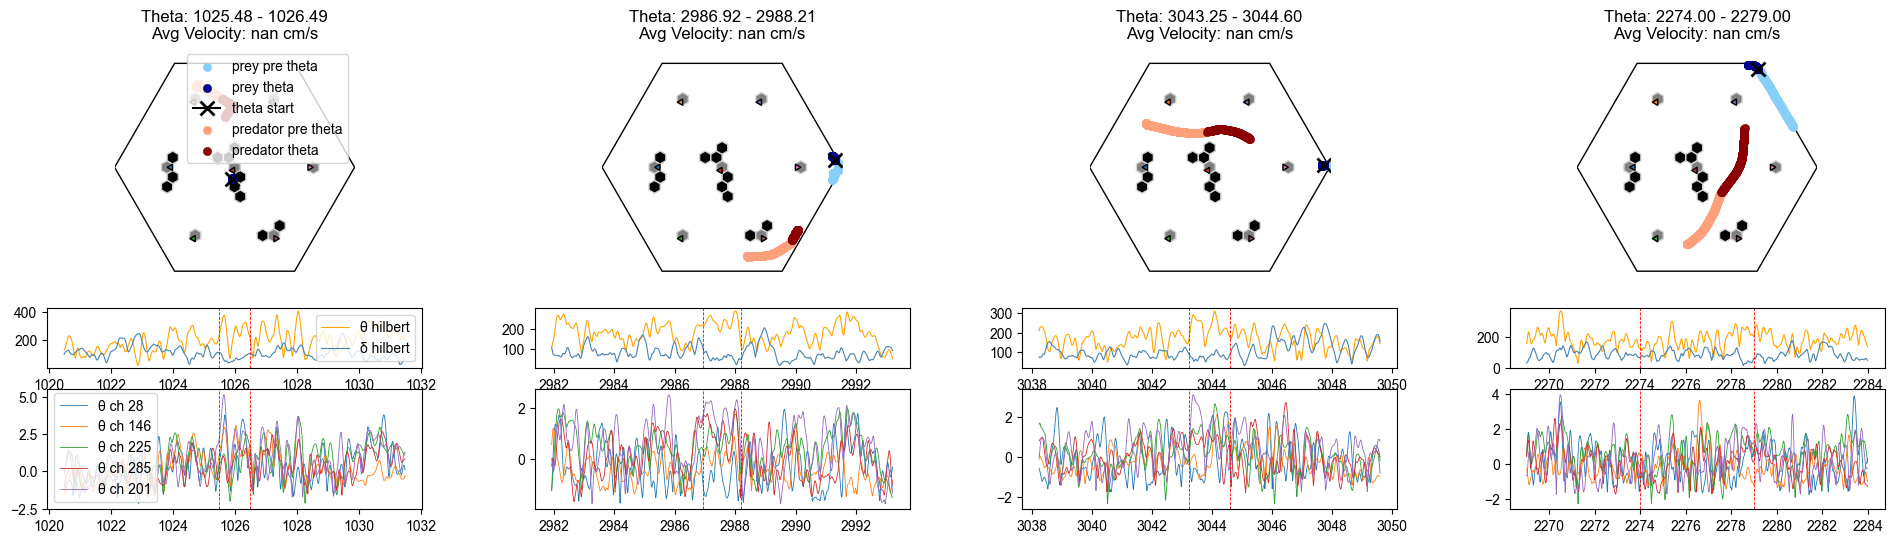

In [39]:
R = load_recording_from_file(r_processed)
OFFSET = 2
OFFSET_THETA = 5

theta_event_times = t[epochs]
avg_velocity = np.zeros(len(epochs))
filtered_epochs = []

for i, epoch in enumerate(epochs):
    t_mask = (R.df.time_stamp > t[epoch[0]]) & (R.df.time_stamp < t[epoch[1]])
    avg_velocity[i] = np.mean(R.df.prey_velocity[t_mask]) * VELOCITY_CM_S
    if not np.isnan(avg_velocity[i]) and avg_velocity[i] < 5:
        filtered_epochs.append(epoch)

filtered_epochs.append([np.argmin(np.abs(t - 2274)), np.argmin(np.abs(t - 2279))])

n_cols = 5
n_epochs = len(filtered_epochs)
n_rows = math.ceil(n_epochs / n_cols)
fig = plt.figure(figsize=(6 * n_cols, 6 * n_rows))

outer = GridSpec(
    math.ceil(n_epochs / n_cols),
    n_cols,
    figure=fig,
    wspace=0.3,
    hspace=0.6
)


for i, epoch in enumerate(filtered_epochs):
    row = i // n_cols
    col = i % n_cols
    inner = outer[row, col].subgridspec(
        3, 1,
        height_ratios=[4, 1, 2],   # top plot bigger
        hspace=0.15
    )
    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1])
    ax3 = fig.add_subplot(inner[2])

    pre_theta_offset, post_theta_offset = t[epoch[0]] - OFFSET, min(t[epoch[1]], t[epoch[0]] + OFFSET)
    t_pre_theta = (R.df.time_stamp > pre_theta_offset) & (R.df.time_stamp < t[epoch[0]])
    t_post_theta = (R.df.time_stamp > t[epoch[0]]) & (R.df.time_stamp < post_theta_offset)

    # ===== PLOT 1 =====
    display_oasis_world(R.experiments[0], R.world, ax=ax1);
    pre_prey = ax1.scatter(R.df['prey_location_x'][t_pre_theta], R.df['prey_location_y'][t_pre_theta], facecolors=(0.53, 0.81, 0.98), linewidths=0.35, label='prey pre theta')
    post_prey = ax1.scatter(R.df['prey_location_x'][t_post_theta], R.df['prey_location_y'][t_post_theta], facecolors=(0, 0, 0.55), linewidths=0.35, label='prey theta')

    closest_theta = (R.df.time_stamp - t[epoch[0]]).abs().idxmin()
    theta_start = ax1.plot(R.df['prey_location_x'][closest_theta], R.df['prey_location_y'][closest_theta], marker='x', color='black', markersize=10, markeredgewidth=2, label='theta start')

    pre_pred = ax1.scatter(R.df['predator_location_x'][t_pre_theta], R.df['predator_location_y'][t_pre_theta], c='lightsalmon', linewidths=0.35, label='predator pre theta')
    post_pred = ax1.scatter(R.df['predator_location_x'][t_post_theta], R.df['predator_location_y'][t_post_theta], c='darkred', linewidths=0.35, label='predator theta')

    ax1.set_xlim(0,1)
    ax1.set_ylim(0,1)
    ax1.set_aspect('equal')
    ax1.set_title(f'Theta: {t[epoch[0]]:.2f} - {t[epoch[1]]:.2f}\nAvg Velocity: {avg_velocity[i]:.2f} cm/s')



    # ===== PLOT 2 =====
    t_start, t_end = t[epoch[0]] - OFFSET_THETA, t[epoch[1]] + OFFSET_THETA
    t_mask_theta = (t > t_start) & (t < t_end)
    t_mask_velo = (R.df.time_stamp > t_start) & (R.df.time_stamp < t_end)

    ax2.plot(t[t_mask_theta], x_theta_hilbert[t_mask_theta], lw=0.8, color='orange', label='θ hilbert')
    ax2.plot(t[t_mask_theta], x_delta_hilbert[t_mask_theta], lw=0.8, color='steelblue', label='δ hilbert')
    # ax2.plot(t[t_mask_theta], theta_delta_ratio[t_mask_theta], lw=0.8, color='black', label='θ/δ ratio')
    ax2.axvline(x=t[epoch[0]], linestyle='--', color='red', lw=0.6)
    ax2.axvline(x=t[epoch[1]], linestyle='--', color='red', lw=0.6)


    # ===== PLOT 3 =====
    for ch in channels:
        hilbert_z = zscore(hilbert_x(x_theta, [ch])) 
        ax3.plot(t[t_mask_theta], hilbert_z[t_mask_theta], lw=0.6, label=f'θ ch {ch}')
    # ax3.plot(t[t_mask_theta], x_theta_hilbert[t_mask_theta], lw=1.5, color='orange', label='θ hilbert')
    ax3.axvline(x=t[epoch[0]], linestyle='--', color='red', lw=0.6)
    ax3.axvline(x=t[epoch[1]], linestyle='--', color='red', lw=0.6)

    if i == 0:
        ax1.legend()
        ax2.legend()
        ax3.legend()


fig.savefig("epochs_051226.png", dpi=150)

# TODO: look at unwrapped angle from hilbert phase theta. how do we calculate phase locking?
# TODO: look at spiking data
# TODO: look at raw theta signal & velocity
# individual channels + avg, velocity


In [29]:
# t_theta = (R.df.time_stamp > t[epochs[8][0]]) & (R.df.time_stamp < t[epochs[8][1]])
# print(t[epochs[8][0]], t[epochs[8][1]])
# print(np.where(t_theta))
# print(R.df.time_stamp[152000])
# plt.plot(R.df.time_stamp)
# print(R.df.time_stamp[np.where(t_theta)])
print(R.get_spikes())

(array([-1.37449908e-02, -1.35114229e-02, -1.35114229e-02, ...,
        3.36015315e+03,  3.36015425e+03,  3.36015486e+03],
      shape=(9975413,)), array([164, 196, 578, ..., 172, 368, 505], shape=(9975413,), dtype=int32),      cluster_id     group KSLabel               probe_name  probe_index
0             0  unsorted     mua  Neuropix-PXI-108.ProbeA            0
1             1  unsorted    good  Neuropix-PXI-108.ProbeA            0
2             2  unsorted     mua  Neuropix-PXI-108.ProbeA            0
3             3  unsorted    good  Neuropix-PXI-108.ProbeA            0
4             4  unsorted    good  Neuropix-PXI-108.ProbeA            0
..          ...       ...     ...                      ...          ...
647         647  unsorted     mua  Neuropix-PXI-108.ProbeA            0
648         648  unsorted    good  Neuropix-PXI-108.ProbeA            0
649         649  unsorted     mua  Neuropix-PXI-108.ProbeA            0
650         650  unsorted     mua  Neuropix-PXI-108.Probe

0          864.037434
1          864.048545
2          864.059756
3          864.070868
4          864.082179
             ...     
152634    2605.754525
152635    2605.765838
152636    2605.776952
152637    2605.790668
152638    2605.801782
Name: time_stamp, Length: 152639, dtype: float64


0           NaN
1         False
2         False
3         False
4         False
          ...  
152634      NaN
152635      NaN
152636      NaN
152637      NaN
152638      NaN
Name: visible, Length: 152639, dtype: object

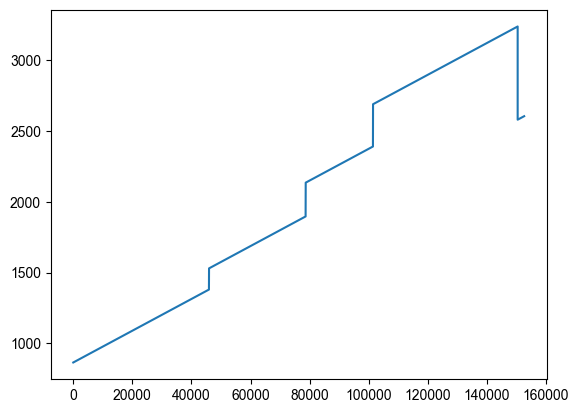

In [72]:
print(R.df['time_stamp'])
plt.plot(R.df['time_stamp'])
# check where timestamp is > event_start, < event_end. then pull out different behaviors relative to the event
R.df['visible'] # NaN means one of agents is not tracked

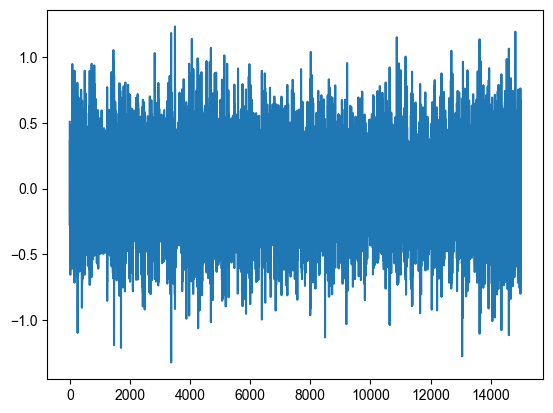

In [ ]:
plt.plot(decimated_signals['Neuropix-PXI-108.ProbeA']['x'][0,0:(FS*10)])